# Training of Noncoupled Nonlinear Memristor Models

In [3]:
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt
import itertools
import random

import functions as fn

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Simple Schottky-Tunneling Current

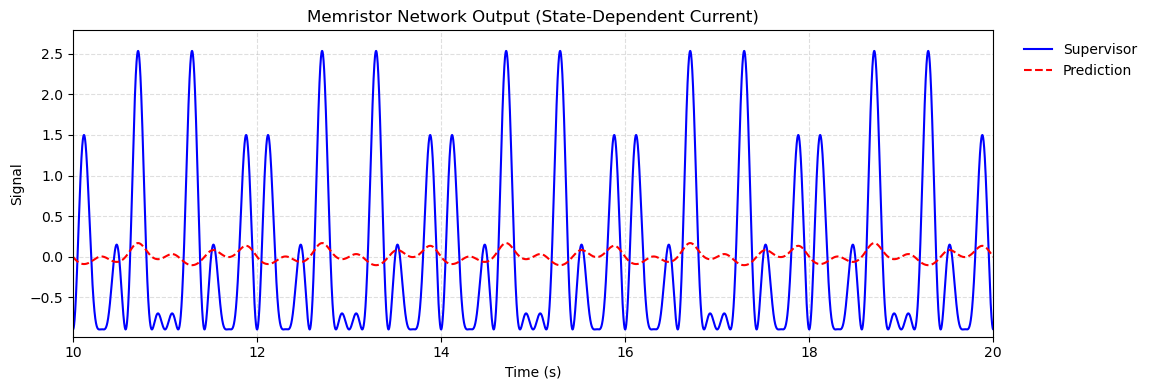

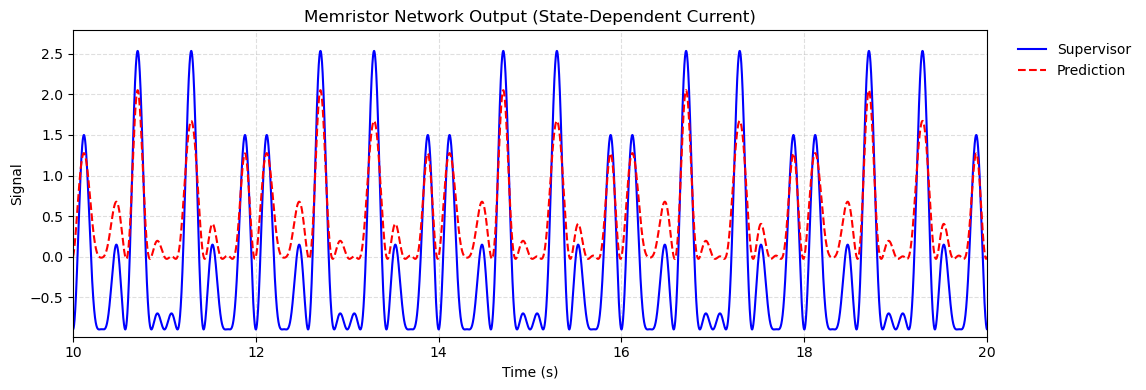

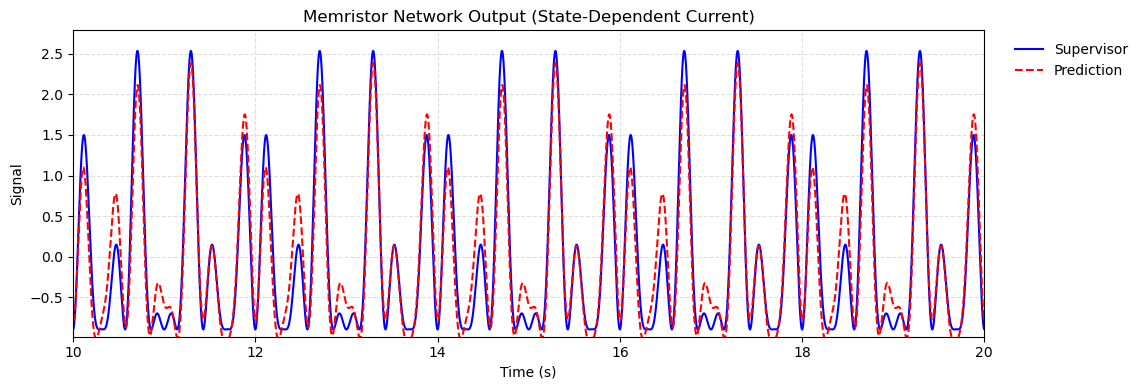

In [4]:
T = 50
dt = 1e-4
t = np.arange(0, T, dt)

N = 300

nu = 1
v_amp = 1/2
v = v_amp*(np.sin(2 * np.pi * t * (1/nu)) + np.sin(5 * np.pi * t * (1/nu)))

# Memristor model parameters
alpha, beta, gamma, delta = 2.5e-6, 0.5, 2.5e-6, 4
lam, eta, tau = 2.5, 3, 0.05
params = [alpha, beta, gamma, delta, lam, eta, tau]

training_sig = v*v
train_times = (5,10)
train_ridge = 1e-10

x = np.random.rand(N)

results1 = fn.sim_train_plot_sst(t,x.copy(),v,nu,N,params,training_sig,train_times,train_ridge,param_var=False,input_delay=False)
results2 = fn.sim_train_plot_sst(t,x.copy(),v,nu,N,params,training_sig,train_times,train_ridge,input_delay=False)
results3 = fn.sim_train_plot_sst(t,x.copy(),v,nu,N,params,training_sig,train_times,train_ridge)



## Using the same functions and parameters in Claudia's paper (MM1-$\tau$ w/ recitifier current)

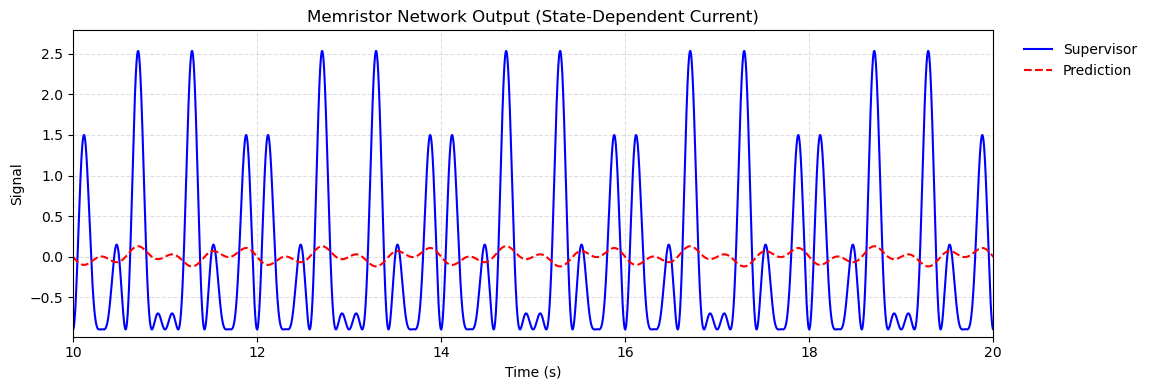

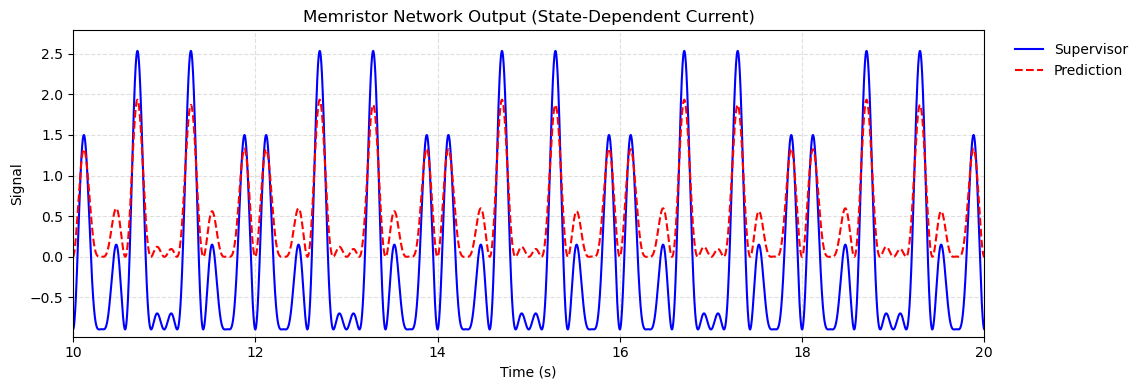

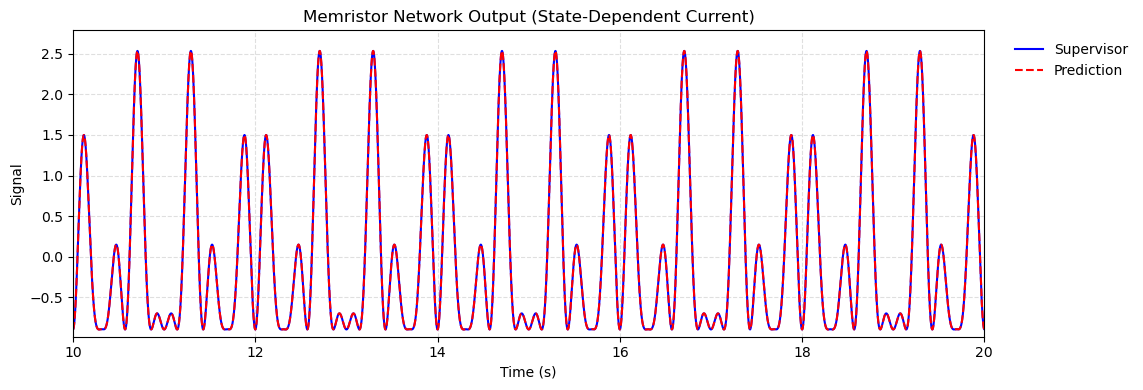

In [8]:
#α1, β1, α2, β2, γ, δ = 6.99172421, 0.09768957, 5.69422726, 0.01078093, 1.5903e-4, 1.00130584
#λ1, λ2, η1, η2, η3, η4, τ =  3.31522859, 3.79686517, 0.18971782, 0.38420470, 0.18220223, 0.49678829, 0.1109234

α1, β1, α2, β2, γ, δ = 6.89172421, 0.09768957 ,3.3451944, 0.010780930, 1.6138e-04, 0.99905798
λ1, λ2, η1, η2, η3, η4, τ =  3.31522859, 3.79686517, 0.18971782, 0.38420470, 0.18220223, 0.49678829, 0.21092344


#α1, β1, α2, β2, γ, δ = 8.345194, 0.1078093, 3.3451944, 0.01078093, 0.005, 1.039012
#λ1, λ2, η1, η2, η3, η4, τ =  3.254168, 3.254168, 0.26103, 0.3249405, 0.26103, 0.3249405, 0.03998672

T = 50
dt = 1e-4
t = np.arange(0, T, dt)
nu = 1
v_amp = 1/2
v = v_amp*(np.sin(2 * np.pi * t * (1/nu)) + np.sin(5 * np.pi * t * (1/nu)))

N = 300

curr_params = [α1, β1, α2, β2, γ, δ]
state_params = [λ1, λ2, η1, η2, η3, η4, τ]


training_sig = v*v
train_times = (5,10)
train_ridge = 1e-10

x = np.random.rand(N)

results1 = fn.sim_train_plot_mm1_rectifier(t,x.copy(),v,nu,N,curr_params,state_params,training_sig,train_times,train_ridge,param_var=False,input_delay=False)
results2 = fn.sim_train_plot_mm1_rectifier(t,x.copy(),v,nu,N,curr_params,state_params,training_sig,train_times,train_ridge,input_delay=False)
results3 = fn.sim_train_plot_mm1_rectifier(t,x.copy(),v,nu,N,curr_params,state_params,training_sig,train_times,train_ridge)
